In [85]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

163.9651


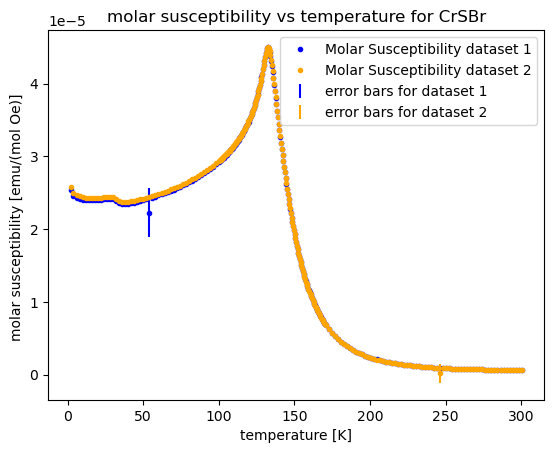

In [86]:
data1 = np.genfromtxt(os.path.join(os.path.dirname(os.getcwd()), "CrSBr/20240523_CrSBr_005_ZFCFC_2K_300K_1000Oe.dc(1).dat"),skip_header=31, delimiter=",",skip_footer=288-32) # creates a 2D array for the first dataset
data2 = np.genfromtxt(os.path.join(os.path.dirname(os.getcwd()), "CrSBr/20240523_CrSBr_005_ZFCFC_2K_300K_1000Oe.dc(1).dat"),skip_header=287, delimiter=",") # creates a 2D array for the second dataset
h_field = data1[:,2]  # in units of Oe
h_field2 = data2[:,2] # in units of Oe
temperature = data1[:,3] # temperature in K
temperature2 = data2[:,3]
magnetization = data1[:,4] # magnetization in units of emu
magnetization2 = data2[:,4] # magnetization in units of emu
magnetization_error = data1[:,5] # error in magnetization
magnetization_error2= data2[:,5] # error in magnetization
mass = 4 # mass of the sample in grams
cr_molar_mass = 51.9961 # molar mass of chromium in g/mol
sulfur_molar_mass = 32.065 # molar mass of sulfur in g/mol
bromine_molar_mass = 79.904 # molar mass of bromine in g/mol
crsbr_molar_mass = cr_molar_mass + sulfur_molar_mass + bromine_molar_mass # molar mass of CrSBr in g/mol
susceptibility_molar = magnetization / h_field * (crsbr_molar_mass / mass) # molar susceptibility in emu/mol Oe
susceptibility_molar2 = magnetization2/h_field2 * (crsbr_molar_mass / mass) # molar susceptibility in emu/mol Oe
susceptibility_error = magnetization_error/h_field * (crsbr_molar_mass/mass) # error in molar susceptibility
susceptibility_error2 = magnetization_error2/h_field2*(crsbr_molar_mass/mass) # error in molar susceptibility

print(crsbr_molar_mass)

#plotting the molar susceptibility as a function of temperature for both datasets with error bars
plt.plot(temperature, susceptibility_molar,".", label="Molar Susceptibility dataset 1", color = "blue") 
plt.errorbar(temperature, susceptibility_molar, yerr = susceptibility_error, fmt = 'none', label = 'error bars for dataset 1', color = "blue")
plt.plot(temperature2, susceptibility_molar2,".", label="Molar Susceptibility dataset 2", color = "orange")
plt.errorbar(temperature2, susceptibility_molar2, yerr = susceptibility_error2, fmt = 'none', label = 'error bars for dataset 2', color = "orange")
plt.xlabel("temperature [K]")
plt.ylabel("molar susceptibility [emu/(mol Oe)] ")
plt.title("molar susceptibility vs temperature for CrSBr")
plt.legend()


We want to calculate the mean of the two datasets, so the two data points that have really large errors, and does not follow the rest, does not contribute as much to the fits.

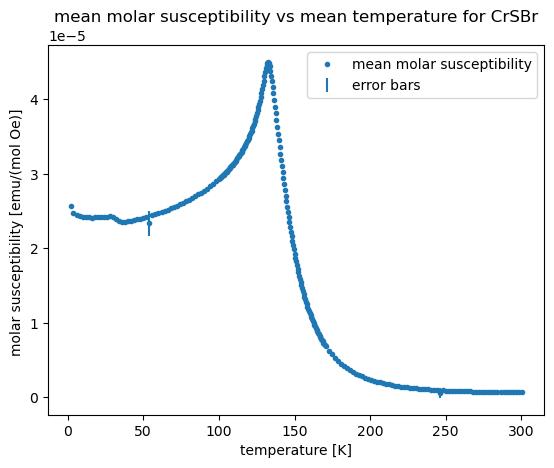

In [87]:
# calculating the means for both temperature and molar susceptibility
temp_mean = (temperature + temperature2)/2
susceptibility_molar_mean = (susceptibility_molar + susceptibility_molar2)/2
susceptibility_error_mean = np.sqrt(susceptibility_error**2 + susceptibility_error2**2)/2

# Plotting the mean susceptibility as a function of temperature
plt.plot(temp_mean, susceptibility_molar_mean, '.', label = "mean molar susceptibility")
plt.errorbar(temp_mean, susceptibility_molar_mean, yerr = susceptibility_error_mean, fmt = 'none', label = 'error bars')
plt.xlabel("temperature [K]")
plt.ylabel("molar susceptibility [emu/(mol Oe)] ")
plt.title("mean molar susceptibility vs mean temperature for CrSBr")
plt.legend()

In [88]:
#Defining a gaussian fit to determine the Néel temperature
def gauss(x, a, b, mu):
    return b * np.exp(-a*(x-mu)**2)

#Defining a linear fit to dertermine if there is a Curie-Weiss behavior
def lin(T, C, b):
    return 1/C*T + b

def CW(T, C, T_c, chi_0):
    return (T+T_c)/(chi_0*(T+T_c) + C)

Gaussian fit parameters: [5.68267125e-03 4.49856587e-05 1.32130882e+02]
Chi-squared for Gaussian fit: 348.7850398024731
Reduced chi-squared for Gaussian fit: 20.516767047204297
uncertainties on the parameters: [4.96708381e-05 1.09125009e-08 1.50780074e-02]


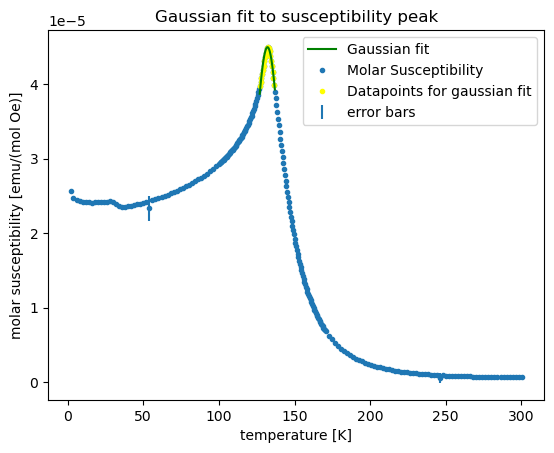

In [89]:
mask_gauss = (temp_mean > 127) & (temp_mean < 137) #We are only interested in the peak from the earlier plot

par_gauss, cov_gauss = curve_fit(gauss, temp_mean[mask_gauss], susceptibility_molar_mean[mask_gauss], p0=[0.1, 1, 132], absolute_sigma=True, sigma = susceptibility_error_mean[mask_gauss]) #Fitting the gaussian
x_gauss = np.linspace(127, 137, 100) # creating the x values for the gaussian fit
y_gauss = gauss(x_gauss, *par_gauss)# Calculating the y values for the gausian fit
print("Gaussian fit parameters:", par_gauss)

# Plotting the gaussian fit along with the entire dataset and the datapoints used for the gaussian fit
plt.plot(x_gauss, y_gauss, color = "green", label="Gaussian fit", zorder =3)
plt.plot(temp_mean, susceptibility_molar_mean,".", label="Molar Susceptibility", zorder = 1)
plt.plot(temp_mean[mask_gauss], susceptibility_molar_mean[mask_gauss], '.', color = 'yellow', label="Datapoints for gaussian fit", zorder=2)
plt.errorbar(temp_mean, susceptibility_molar_mean, yerr = susceptibility_error_mean, fmt = 'none', label = 'error bars', zorder=0)
plt.xlabel("temperature [K]")
plt.ylabel("molar susceptibility [emu/(mol Oe)]")
plt.title("Gaussian fit to susceptibility peak")
plt.legend()

#Calculating the reduced chi-squared for the gaussian fit
chi_squared_gauss = np.sum(((susceptibility_molar_mean[mask_gauss] - gauss(temp_mean[mask_gauss], *par_gauss)) / susceptibility_error[mask_gauss])**2)
print("Chi-squared for Gaussian fit:", chi_squared_gauss)
print("Reduced chi-squared for Gaussian fit:", chi_squared_gauss / (len(temp_mean[mask_gauss]) - len(par_gauss)))
print("uncertainties on the parameters:", np.sqrt(np.diag(cov_gauss)))

192067166.29505214
[-24102.46865886  28111.44563296]


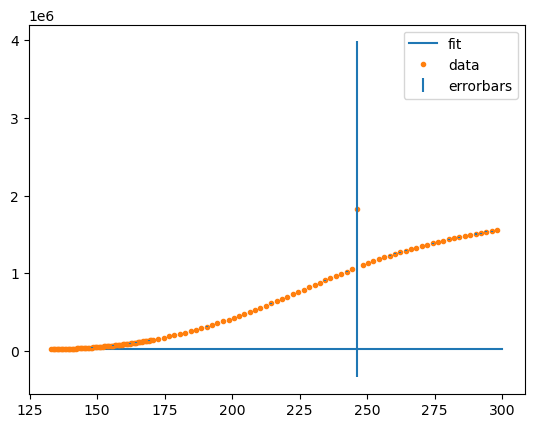

In [90]:
t_min, t_max = 133, 300 # define the temperature range for the Curie-Weiss fit

susceptibility_molar_mean_inverted = susceptibility_molar_mean**(-1) #Inverting the susceptibility, so it becomes linear
mask_inv = (temp_mean > t_min) & (temp_mean < t_max) # Creating the mask, so we only fit in the paramagnetic region

susceptibility_molar_mean_inverted_error = susceptibility_error_mean*(susceptibility_molar_mean_inverted**2) #Calculating the error

par, cov = curve_fit(lin, temp_mean[mask_inv], susceptibility_molar_mean_inverted[mask_inv], p0 = [1/(0.25),132], absolute_sigma= True, sigma= susceptibility_molar_mean_inverted_error[mask_inv]) #Fitting the linear Curie-Weiss law tp the data


X = np.linspace(t_min, t_max, len(temp_mean[mask_inv])) #Creating the X values
Y = lin(X, *par) #Calculating the y values


#Plotting the fit with the data
plt.plot(X,Y, label = 'fit')
plt.plot(temp_mean[mask_inv], susceptibility_molar_mean_inverted[mask_inv], '.', label = 'data')
plt.errorbar(temp_mean[mask_inv], susceptibility_molar_mean_inverted[mask_inv], yerr = susceptibility_molar_mean_inverted_error[mask_inv], fmt = 'None', label = 'errorbars')
plt.legend()

#Calculating the reduced chi-squared for the Curie-Weiss fit
chi_squared = np.sum((susceptibility_molar_mean_inverted[mask_inv] - Y)**2/susceptibility_molar_mean_inverted_error[mask_inv])
reduced_chi_squared = chi_squared/(len(temp_mean[mask_inv] - len(par)))

print(reduced_chi_squared)
print(par)

In [91]:
def chi_min(T_min, T_max, min, func, guess, temp, susceptibility, error):
    #Creating lists to store the results of the Curie-Weiss fitting for different temperature ranges
    chi_squared_list = []
    num_data_list = []
    par_list = []
    T_list = []
    covariance_list = []
    fit = 0
    if min == True:
        T = T_min
        print(1)
        while T < T_max: #A loop to find the reduced chi-squared for different temperature ranges
            #Doing the same fitting procedure as before
            mask = (temp > T) & (temp < t_max)
            par, cov = curve_fit(func, temp[mask], susceptibility[mask], p0= guess, absolute_sigma= True, sigma = error[mask], maxfev = 10000000) #Fitting to the data
            if len(temp[mask]) - len(par) <= 0:#Just in case there are not enough data points to fit
                break   
            par_list.append(par) # storing the parameters for each fit
            x_weiss_inv = np.linspace(np.min(temp[mask]), np.max(temp[mask]), len(temp[mask]))
            y_weiss_inv = func(x_weiss_inv, *par)
            #Calculating the reduced chi-squared for each fit and storing the results
            diff_y = -y_weiss_inv + susceptibility[mask]
            chi_squared = np.sum(diff_y**2/error[mask]**2)
            reduced_chi_squared = chi_squared/(len(temp[mask]) - len(par))
            if reduced_chi_squared < 1: #No need to go lower temperatures if already have a perfect fit
                break
            T_list.append(T)
            T += 1 # lowering the minimum temperature for the fit with one kelvin
            chi_squared_list.append((reduced_chi_squared)) # added the chi squared to the list
            num_data_list.append(len(temp[mask])) # added the number of data points used for each fit
            covariance_list.append(cov) # added the covariance used for each fit
            # print(T)
            fit += 1
    else:
        T= T_max
        print(2)
        while T > T_min: #A loop to find the reduced chi-squared for different temperature ranges
            #Doing the same fitting procedure as before
            mask = (temp > T_min) & (temp < T)
            par, cov = curve_fit(func, temp[mask], susceptibility[mask], p0=guess, absolute_sigma= True, sigma = error[mask], maxfev = 10000000) #Fitting to the data
            if len(temp[mask]) - len(par) <= 0:#Just in case there are not enough data points to fit
                break   
            par_list.append(par) # storing the parameters for each fit
            x = np.linspace(np.min(temp[mask]), np.max(temp[mask]), len(temp[mask]))
            y = func(x, *par)
            #Calculating the reduced chi-squared for each fit and storing the results
            diff_y = susceptibility[mask] - y
            chi_squared = np.sum(diff_y**2/error[mask]**2)
            reduced_chi_squared = chi_squared/(len(temp[mask]) - len(par))
            if reduced_chi_squared < 1: #No need to go lower temperatures if already have a perfect fit
                break
            T_list.append(T)
            T -= 1
            chi_squared_list.append((reduced_chi_squared)) # added the chi squared to the list
            num_data_list.append(len(temp[mask])) # added the number of data points used for each fit
            covariance_list.append(cov) # added the covariance used for each fit
            # print(T)

    
    #Changes the lists to a numpy arrays to use the functions of numpy
    chi_squared_array = np.array(chi_squared_list)
    par_array = np.array(par_list)
    num_data_array = np.array(num_data_list)
    T_array = np.array(T_list)
    covariance_array = np.array(covariance_list)

    return  chi_squared_array, par_array, num_data_array, T_array, covariance_array


1


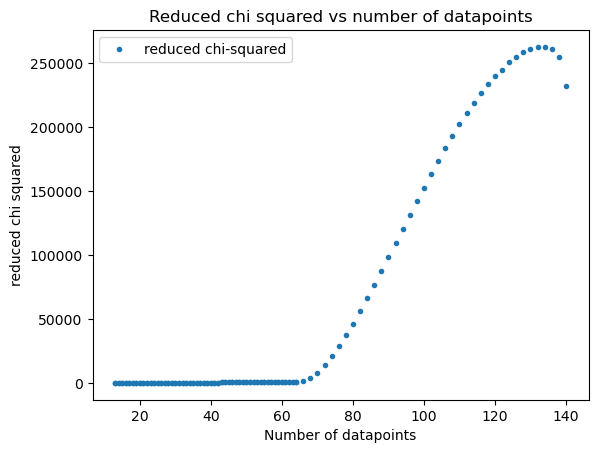

In [92]:
a,b,c,d,e = chi_min(133,300,True,lin, [0.0001, 132], temp_mean, susceptibility_molar_mean_inverted, susceptibility_molar_mean_inverted_error)
plt.plot(c, a, '.', label = "reduced chi-squared")
plt.xlabel('Number of datapoints')
plt.ylabel('reduced chi squared')
plt.title('Reduced chi squared vs number of datapoints')
plt.legend()



200
[363.95204221 363.95204221]
50
[ 7.66967997e-05 -2.17530345e+06]
[5.54194126e-08 2.14283335e+03]
1.0710225553381323


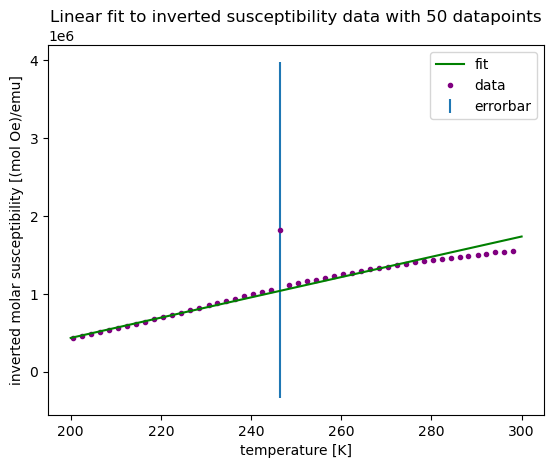

In [93]:
#Plotting the the best fit with the highest amount of datapoints
t_min = d[np.where(c == 50)]
t_min = t_min[1]
t_max = 300
print(t_min)
mask_inv = (temp_mean > t_min) & (temp_mean < t_max)

cov_inv = e[np.where(c == 50)]
par_inv = b[np.where(c == 50)]
error_par_inv = np.sqrt(np.diag(cov_inv[1]))
X = np.linspace(t_min, t_max)
Y = lin(X, *par_inv[1])


print(a[np.where(c == 50)])
plt.plot(X, Y, color ='green', label = 'fit', zorder = 3)
plt.plot(temp_mean[mask_inv], susceptibility_molar_mean_inverted[mask_inv], '.', color = 'purple', label = 'data', zorder = 2)
plt.errorbar(temp_mean[mask_inv], susceptibility_molar_mean_inverted[mask_inv], yerr = susceptibility_molar_mean_inverted_error[mask_inv], fmt = 'None', label = 'errorbar', zorder = 0)
plt.title("Linear fit to inverted susceptibility data with 50 datapoints")
plt.xlabel("temperature [K]")
plt.ylabel("inverted molar susceptibility [(mol Oe)/emu]")
plt.legend()
print(len(temp_mean[mask_inv]))
print(par_inv[1])
print(error_par_inv)

print(a[-1])

[ 7.66968015e-05 -2.17530339e+06]
[[3.07131146e-15 1.18167577e-04]
 [1.18167577e-04 4.59173484e+06]]
Reduced chi-squared without outlier: 366.61047359120437


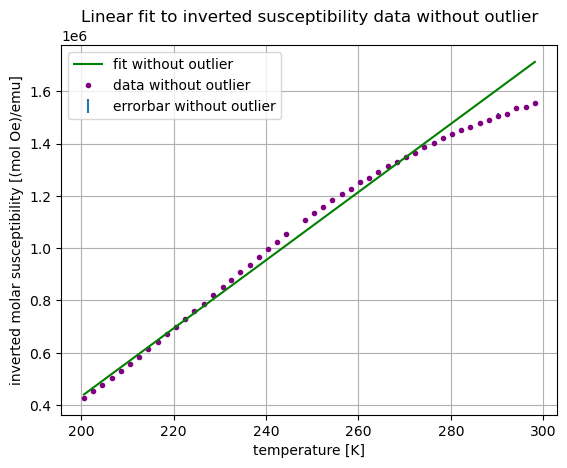

In [94]:
mask_inv = (temp_mean > 200) & (temp_mean < 300)
data_mod_lin = np.delete(susceptibility_molar_mean_inverted[mask_inv],np.argmax(susceptibility_molar_mean_inverted[mask_inv])) #Removing the datapoint with the highest susceptibility, since it has a very high influence on the fit
temp_mod_lin = np.delete(temp_mean[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv])) #Removing the corresponding temperature for the removed datapoint
error_mod_lin = np.delete(susceptibility_molar_mean_inverted_error[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv])) #Removing the corresponding error for the removed datapoint

par_mod_lin, cov_mod_lin = curve_fit(lin, temp_mod_lin, data_mod_lin, p0 = [0.00001,132], absolute_sigma= True, sigma= error_mod_lin) #Fitting the linear Curie-Weiss law to the data
X_mod = np.linspace(np.min(temp_mod_lin), np.max(temp_mod_lin), len(temp_mod_lin))
Y_mod = lin(X_mod, *par_mod_lin)
print(par_mod_lin)
print(cov_mod_lin)

plt.plot(X_mod, Y_mod, color ='green', label = 'fit without outlier', zorder = 3)
plt.plot(temp_mod_lin, data_mod_lin, '.', color = 'purple', label = 'data without outlier', zorder = 2)
plt.errorbar(temp_mod_lin, data_mod_lin, yerr = error_mod_lin, fmt = 'None', label = 'errorbar without outlier', zorder = 0)
plt.title("Linear fit to inverted susceptibility data without outlier")
plt.xlabel("temperature [K]")
plt.ylabel("inverted molar susceptibility [(mol Oe)/emu]")
plt.legend()
plt.grid()

#Calculating the reduced chi-squared for the fit without the outlier
diff_y_mod = data_mod_lin - Y_mod
chi_squared_mod = np.sum(diff_y_mod**2/error_mod_lin**2)
reduced_chi_squared_mod = chi_squared_mod/(len(temp_mod_lin) - len(par_mod_lin))
print("Reduced chi-squared without outlier:", reduced_chi_squared_mod)


179
[425.91032506 425.91032506]
60
[ 7.87506107e-05 -2.09633237e+06]
[3.51325963e-08 1.16375323e+03]


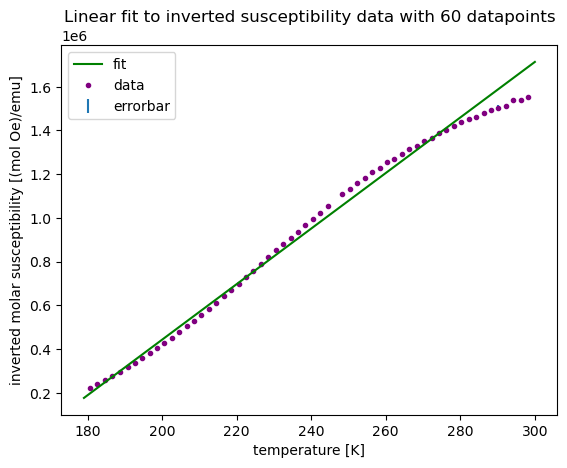

In [95]:
#Plotting the the best fit with the highest amount of datapoints
t_min = d[np.where(c == 60)]
t_min = t_min[0]
print(t_min)
mask_inv = (temp_mean > t_min) & (temp_mean < t_max)

cov_inv = e[np.where(c == 60)]
par_inv = b[np.where(c == 60)]
error_par_inv = np.sqrt(np.diag(cov_inv[0]))
X = np.linspace(t_min, t_max)
Y = lin(X, *par_inv[0])


print(a[np.where(c == 60)])
plt.plot(X, Y, color ='green', label = 'fit', zorder = 3)
plt.plot(np.delete(temp_mean[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv])), np.delete(susceptibility_molar_mean_inverted[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv])), '.', color = 'purple', label = 'data', zorder = 2)
plt.errorbar(np.delete(temp_mean[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv])), np.delete(susceptibility_molar_mean_inverted[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv])), yerr = np.delete(susceptibility_molar_mean_inverted_error[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv])), fmt = 'None', label = 'errorbar', zorder = 0)
plt.title("Linear fit to inverted susceptibility data with 60 datapoints")
plt.xlabel("temperature [K]")
plt.ylabel("inverted molar susceptibility [(mol Oe)/emu]")
plt.legend()
print(len(temp_mean[mask_inv]))
print(par_inv[0])
print(error_par_inv)

50
123.29924430565684
5.1571939144085095e-05 -177.94727915341713 1.896605359376572e-07
[1.77091946e-07 8.74874152e-02 1.49946024e-09]


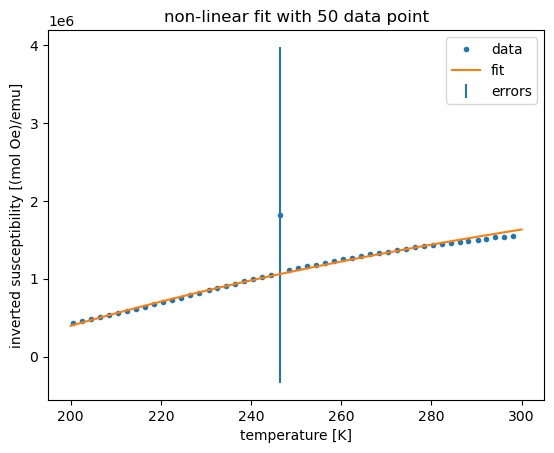

In [96]:
# temp_mean_mod, susceptibility_molar_mean_inverted_mod = np.delete(temp_mean[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv])), np.delete(susceptibility_molar_mean_inverted[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv]))
# susceptibility_molar_mean_inverted_error_mod = np.delete(susceptibility_molar_mean_inverted_error[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv]))
mask_inv = (temp_mean > 200) & (temp_mean < 300)
par, cov = curve_fit(CW, temp_mean[mask_inv], susceptibility_molar_mean_inverted[mask_inv],p0 = [1/110000,180, 0.1], absolute_sigma= True, sigma= susceptibility_molar_mean_inverted_error[mask_inv], maxfev = 1000000)
X = np.linspace(200, 300, len(temp_mean[mask_inv]))
Y = CW(X,*par)

plt.plot(temp_mean[mask_inv], susceptibility_molar_mean_inverted[mask_inv], '.', label = 'data')
plt.errorbar(temp_mean[mask_inv], susceptibility_molar_mean_inverted[mask_inv], yerr = susceptibility_molar_mean_inverted_error[mask_inv], fmt = 'None', label = 'errors')
plt.plot(X,Y, label = 'fit')
plt.xlabel('temperature [K]')
plt.ylabel('inverted susceptibility [(mol Oe)/emu]')
plt.title('non-linear fit with 50 data point')
plt.legend()
print(len(temp_mean[mask_inv]))

diff_y = susceptibility_molar_mean_inverted[mask_inv] - Y
chi_squared = np.sum(diff_y**2/susceptibility_molar_mean_inverted_error[mask_inv]**2)
reduced_chi_squared = chi_squared/(len(temp_mean[mask_inv]) - len(par))
print(reduced_chi_squared)
print(*par)
print(np.sqrt(np.diag(cov)))

50
169.97852566539058
5.157195146720768e-05 -177.94727327651148 1.8966044379484691e-07
[1.77091665e-07 8.74873076e-02 1.49945887e-09]


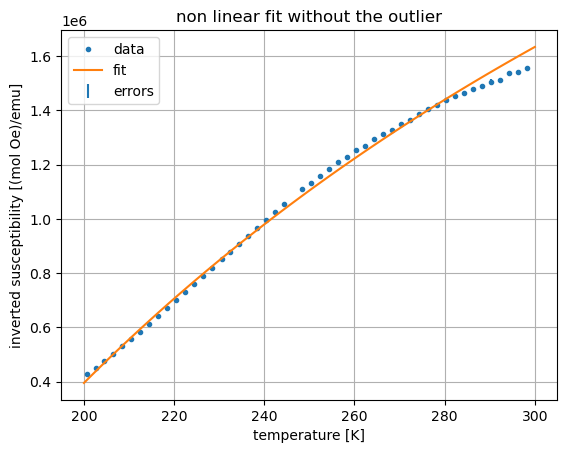

In [97]:
temp_mean_mod, susceptibility_molar_mean_inverted_mod = np.delete(temp_mean[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv])), np.delete(susceptibility_molar_mean_inverted[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv]))
susceptibility_molar_mean_inverted_error_mod = np.delete(susceptibility_molar_mean_inverted_error[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv]))

par, cov = curve_fit(CW, temp_mean_mod, susceptibility_molar_mean_inverted_mod,p0 = [1/110000, 180, 0.2], absolute_sigma= True, sigma= susceptibility_molar_mean_inverted_error_mod, maxfev = 1000000)
X = np.linspace(200, 300, len(temp_mean_mod))
Y = CW(X,*par)

plt.plot(temp_mean_mod, susceptibility_molar_mean_inverted_mod, '.', label = 'data')
plt.errorbar(temp_mean_mod, susceptibility_molar_mean_inverted_mod, yerr = susceptibility_molar_mean_inverted_error_mod, fmt = 'None', label = 'errors')
plt.plot(X,Y, label = 'fit')
plt.xlabel('temperature [K]')
plt.ylabel('inverted susceptibility [(mol Oe)/emu]')
plt.title('non linear fit without the outlier')
plt.legend()
print(len(temp_mean[mask_inv]))

diff_y = susceptibility_molar_mean_inverted_mod - Y
chi_squared = np.sum(diff_y**2/susceptibility_molar_mean_inverted_error_mod**2)
reduced_chi_squared = chi_squared/(len(temp_mean_mod) - len(par))
print(reduced_chi_squared)
print(*par)
print(np.sqrt(np.diag(cov)))
plt.grid()

2


Text(0.5, 1.0, 'reduced chi squared vs number of data point (nonlinear)')

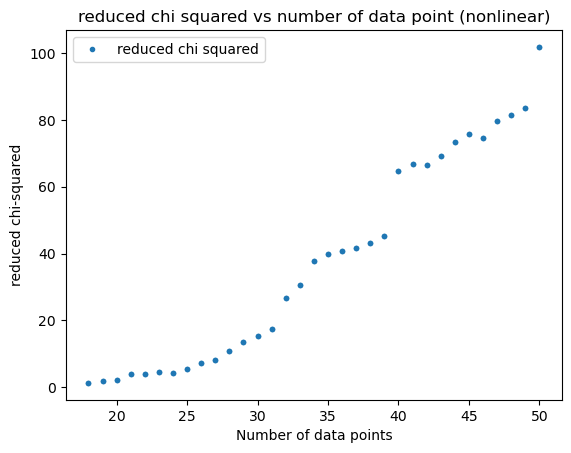

In [98]:
chi, param, datapoints, temp, covariance = chi_min(200,300, False, CW, [1/11000, 180, 0.1], temp_mean, susceptibility_molar_mean_inverted, susceptibility_molar_mean_inverted_error)
plt.plot(datapoints, chi, '.', label = 'reduced chi squared')
plt.xlabel('Number of data points')
plt.ylabel('reduced chi-squared')
plt.legend()
plt.title('reduced chi squared vs number of data point (nonlinear)')

200
[45.39096831 45.39096831]
39
[ 6.11280191e-05 -1.74265929e+02  9.18350327e-08]
[3.04077409e-07 1.28435373e-01 2.66925467e-09]


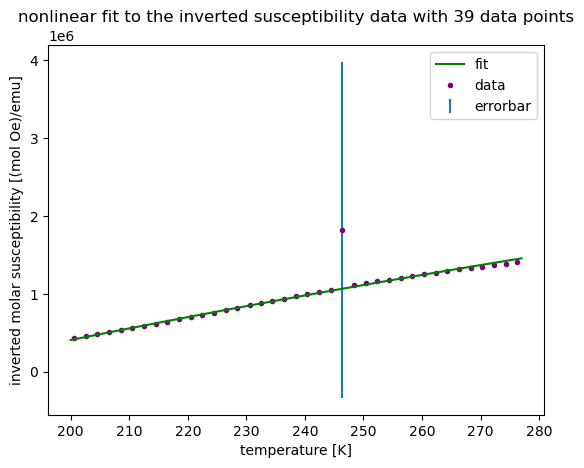

In [99]:
#Plotting the the best fit with the highest amount of datapoints
t_max = temp[np.where(datapoints == 39)]
t_max = t_max[1]
t_min = 200
print(t_min)
mask_inv = (temp_mean > t_min) & (temp_mean < t_max)

cov_inv = covariance[np.where(datapoints== 39)]
par_inv = param[np.where(datapoints == 39)]
error_par_inv = np.sqrt(np.diag(cov_inv[1]))
X = np.linspace(t_min, t_max, len(temp_mean[mask_inv]))
Y = CW(X, *par_inv[1])


print(chi[np.where(datapoints == 39)])
plt.plot(X, Y, color ='green', label = 'fit', zorder = 3)
plt.plot(temp_mean[mask_inv], susceptibility_molar_mean_inverted[mask_inv], '.', color = 'purple', label = 'data', zorder = 2)
plt.errorbar(temp_mean[mask_inv], susceptibility_molar_mean_inverted[mask_inv], yerr = susceptibility_molar_mean_inverted_error[mask_inv], fmt = 'None', label = 'errorbar', zorder = 0)
plt.title("nonlinear fit to the inverted susceptibility data with 39 data points")
plt.xlabel("temperature [K]")
plt.ylabel("inverted molar susceptibility [(mol Oe)/emu]")
plt.legend()
print(len(temp_mean[mask_inv]))
print(par_inv[1])
print(error_par_inv)

[45.39096831 45.39096831]


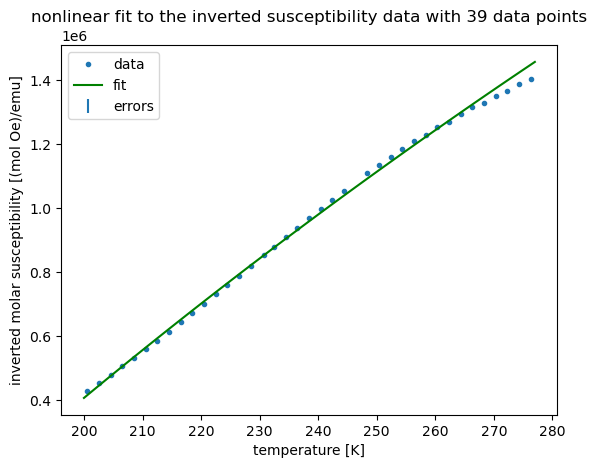

In [100]:
temp_mean_mod, susceptibility_molar_mean_inverted_mod = np.delete(temp_mean[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv])), np.delete(susceptibility_molar_mean_inverted[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv]))
susceptibility_molar_mean_inverted_error_mod = np.delete(susceptibility_molar_mean_inverted_error[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv]))

plt.plot(temp_mean_mod, susceptibility_molar_mean_inverted_mod, '.', label = 'data')
plt.errorbar(temp_mean_mod, susceptibility_molar_mean_inverted_mod, yerr = susceptibility_molar_mean_inverted_error_mod, fmt = 'None', label = 'errors')

print(chi[np.where(datapoints == 39)])
plt.plot(X, Y, color ='green', label = 'fit', zorder = 3)
plt.title("nonlinear fit to the inverted susceptibility data with 39 data points")
plt.xlabel("temperature [K]")
plt.ylabel("inverted molar susceptibility [(mol Oe)/emu]")
plt.legend()

156.57855396009134
5.157195146720768e-05 -177.94727327651148 1.8966044379484691e-07
[1.77091665e-07 8.74873076e-02 1.49945887e-09]
298.18399999999997


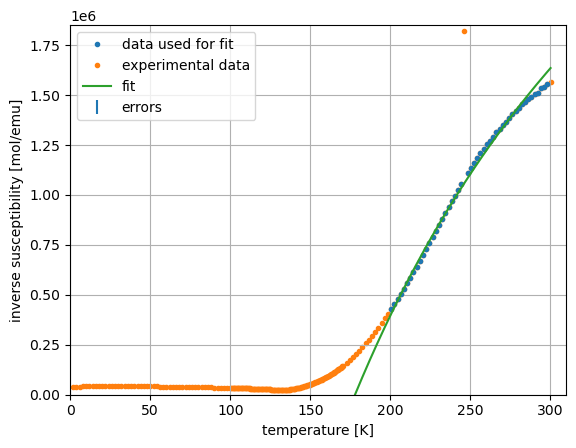

In [101]:
mask_inv = (temp_mean > 200) & (temp_mean < np.max(temp_mean))
data_mod = np.delete(susceptibility_molar_mean_inverted[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv]))
temp_mod = np.delete(temp_mean[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv]))
error_mod = np.delete(susceptibility_molar_mean_inverted_error[mask_inv], np.argmax(susceptibility_molar_mean_inverted[mask_inv]))

par, cov = curve_fit(CW, temp_mod, data_mod,p0 = [1/110000, 180, 0.2], absolute_sigma= True, sigma= error_mod, maxfev = 1000000)
X = np.linspace(np.min(temp_mod), np.max(temp_mod), len(temp_mod))
X1 = np.linspace(150, np.max(temp_mean), 10000000)
Y = CW(X,*par)
Y1 = CW(X1, *par)

plt.plot(temp_mod, data_mod, '.', label = 'data used for fit', zorder = 2)
plt.errorbar(temp_mod, data_mod, yerr = error_mod, fmt = 'None', label = 'errors')
plt.plot(temp_mean, susceptibility_molar_mean_inverted, '.', label = 'experimental data', zorder = 1)
# plt.plot(X,Y, label = 'fit')
plt.plot(X1, Y1, label = 'fit')
plt.xlabel('temperature [K]')
plt.ylabel('inverse susceptibility [mol/emu]')
# plt.title('non linear fit without the outlier')
plt.grid()
plt.legend()
plt.ylim(0, 1.85e6)
plt.xlim(0,310)

diff_y = data_mod - Y
chi_squared = np.sum(diff_y**2/error_mod**2)
reduced_chi_squared = chi_squared/(len(temp_mod) - len(par))
print(reduced_chi_squared)
print(*par)
print(np.sqrt(np.diag(cov)))
print(np.max(temp_mod))

2


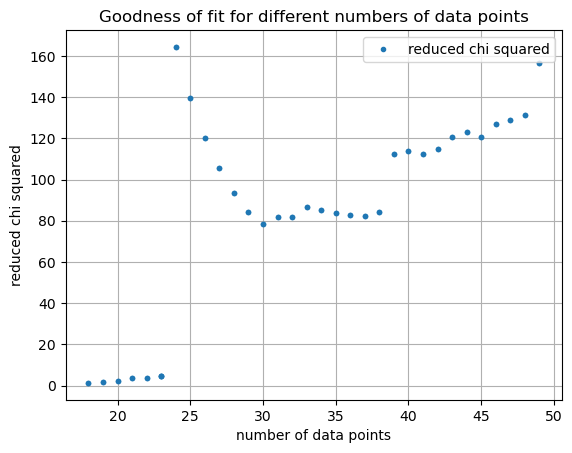

In [102]:
mask_inv = (temp_mean > 200) & (temp_mean < 300)
chi2, param2, datapoints2, temp2, covariance2 = chi_min(200,300, False, CW, [1/11000, 180, 0.1], temp_mod, data_mod, error_mod)

plt.plot(datapoints2, chi2, '.', label = 'reduced chi squared')
plt.xlabel("number of data points")
plt.ylabel("reduced chi squared")
plt.title("Goodness of fit for different numbers of data points")
plt.legend()
plt.grid()

2


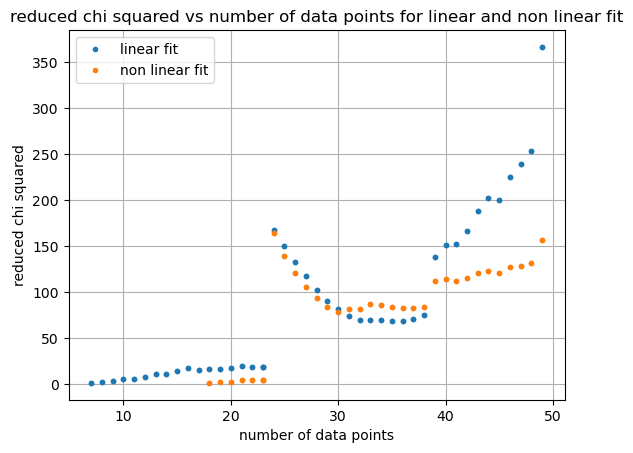

In [103]:
chi3, param3, datapoints3, temp3, covariance3 = chi_min(200,300, False, lin, [1/11000, 180], temp_mod_lin, data_mod_lin, error_mod_lin)
plt.plot(datapoints3, chi3, '.', label = 'linear fit')
plt.plot(datapoints2, chi2, '.', label = 'non linear fit')
plt.xlabel("number of data points")
plt.ylabel("reduced chi squared")
plt.title("reduced chi squared vs number of data points for linear and non linear fit")
plt.legend()
plt.grid()


In [104]:
#Plotting the the best fit with the highest amount of datapoints
t_max = temp3[np.where(datapoints3 == 35)]
t_max = t_max[1]
t_min = 200
print(t_min)
mask_inv = (temp_mean > t_min) & (temp_mean < t_max)

cov_inv = covariance3[np.where(datapoints3== 35)]
par_inv = param3[np.where(datapoints3 == 35)]
error_par_inv = np.sqrt(np.diag(cov_inv[1]))

print(len(temp_mean[mask_inv]))
print(par_inv[1])
# print(1/par_inv[1])
print(error_par_inv)

200
36
[ 7.15339932e-05 -2.38040900e+06]
[6.36806006e-08 2.77893676e+03]
